# Task 2: Symbolic Conditioned Generation — Chord-to-Melody
Team members for this task: [your names here]

## 1. Exploratory Analysis, Data Collection, Pre-processing, and Discussion

### 1.1 Dataset Context

POP909 is a dataset of 909 professionally arranged pop songs in MIDI format, introduced in the paper *POP909: A Pop-song Dataset for Music Arrangement Generation* (Wang et al., ISMIR 2020). Each song folder contains a main MIDI file with three tracks — `MELODY`, `BRIDGE`, and `PIANO` — along with text annotations for beats, chords, and keys.

For this task, we use the chord annotations and the `MELODY` track. Our task is **symbolic conditioned generation**: given a chord progression as input, generate a matching melody. This is a sequence-to-sequence problem where:
- **Input (condition):** chord progression from `chord_midi.txt`
- **Output (target):** melody note sequence from the `MELODY` track of the main MIDI file

This dataset was chosen because it provides clean, aligned chord and melody data for 909 pop songs, making it well suited for learning the relationship between harmonic structure and melodic content.

### 1.2 Install and Load Libraries

In [23]:
!pip install pretty_midi pandas matplotlib numpy music21

import pretty_midi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import music21
import music21.harmony

# ── Config ────────────────────────────────────────────────────────────────────
CONFIG = {
    "RAW_DIR":      "data/raw/POP909",
    "PROCESSED_DIR":"data/processed",
    "OUTPUT_DIR":   "data/outputs",
    "TICKS_PER_BEAT": 4,
    "TARGET_KEY":   "C",
    "MAX_SEQ_LEN":  512,
    "BATCH_SIZE":   32,
    "EPOCHS":       100,
    "EMBED_DIM":    128,
    "NUM_HEADS":    4,
    "NUM_LAYERS":   3,
    "LR":           1e-3,
}

# ── Song directory list (used by EDA cells) ───────────────────────────────────
DATA_DIR  = Path(CONFIG["RAW_DIR"])
song_dirs = sorted([d for d in DATA_DIR.iterdir() if d.is_dir()])
print(f"Found {len(song_dirs)} song directories")

Found 909 song directories


### 1.3 Data Loading

In [24]:
def load_chords(chord_path):
    """Parse chord_midi.txt into a list of dicts with start, end, label, duration."""
    chords = []
    with open(chord_path) as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) == 3:
                start, end, label = float(parts[0]), float(parts[1]), parts[2]
                chords.append({
                    'start': start,
                    'end': end,
                    'label': label,
                    'duration': end - start
                })
    return chords

def load_melody(midi_path):
    """Extract MELODY track (track 0) from a POP909 MIDI file."""
    mid = pretty_midi.PrettyMIDI(str(midi_path))
    melody_track = mid.instruments[0]  # Track 0 is always MELODY in POP909
    return melody_track.notes, mid.get_end_time()

# Find all song directories
song_dirs = sorted([d for d in DATA_DIR.iterdir() if d.is_dir()])
print("Number of songs found:", len(song_dirs))
print("First song directory:", song_dirs[0])

Number of songs found: 909
First song directory: data/raw/POP909/001


### 1.4 Dataset Inspection

In [25]:
# Inspect a single song to understand the data format
example_dir = song_dirs[0]
example_midi_path = example_dir / f"{example_dir.name}.mid"
example_chord_path = example_dir / "chord_midi.txt"

# Inspect MIDI tracks
mid = pretty_midi.PrettyMIDI(str(example_midi_path))
print("Number of instruments:", len(mid.instruments))
for i, inst in enumerate(mid.instruments):
    print(f"  Track {i}: '{inst.name}' | program={inst.program} | notes={len(inst.notes)}")

print()

# Inspect chord file
chords_example = load_chords(example_chord_path)
print(f"Total chord events: {len(chords_example)}")
print(f"Unique chord labels: {len(set(c['label'] for c in chords_example))}")
print()
print("First 5 chord events:")
for c in chords_example[:5]:
    print(f"  {c['start']:.2f}s -> {c['end']:.2f}s : {c['label']}")

Number of instruments: 3
  Track 0: 'MELODY' | program=0 | notes=264
  Track 1: 'BRIDGE' | program=0 | notes=307
  Track 2: 'PIANO' | program=0 | notes=985

Total chord events: 155
Unique chord labels: 10

First 5 chord events:
  0.06s -> 0.72s : N
  0.72s -> 1.39s : N
  1.39s -> 2.06s : N
  2.06s -> 2.72s : N
  2.72s -> 4.06s : B:maj


In [26]:
# Inspect the MELODY track notes
melody_notes_example, duration_example = load_melody(example_midi_path)

notes_preview = []
for n in melody_notes_example:
    notes_preview.append({
        "pitch": n.pitch,
        "start": n.start,
        "end": n.end,
        "duration": n.end - n.start,
        "velocity": n.velocity
    })

notes_preview_df = pd.DataFrame(notes_preview)
print(f"Song duration: {duration_example:.1f} seconds")
print(f"Total melody notes: {len(notes_preview_df)}")
print()
notes_preview_df.head()

Song duration: 196.0 seconds
Total melody notes: 264



,pitch,start,end,duration,velocity
0,61,12.722190,12.818024,0.095833,115
1,63,12.888857,12.951357,0.062500,109
2,66,13.055523,13.123578,0.068055,118
3,68,13.222189,13.305522,0.083333,112
4,70,13.388855,13.498577,0.109722,112


In [27]:
notes_preview_df.describe()

,pitch,start,end,duration,velocity
count,264.000000,264.000000,264.000000,264.000000,264.000000
mean,65.613636,89.528817,89.787612,0.258796,114.136364
std,2.740064,50.478127,50.482314,0.295765,2.441008
min,61.000000,12.722190,12.818024,0.062500,109.000000
25%,63.000000,45.180443,45.259956,0.090278,112.000000
50%,66.000000,89.805331,89.934497,0.136805,115.000000
75%,68.000000,141.096869,141.168744,0.227777,115.000000
max,70.000000,181.055103,182.275933,1.299997,118.000000


### 1.5 Pre-processing

We scale data loading to all 909 songs, collecting chord events and melody notes into DataFrames for analysis. We drop chord events labeled `N` (no chord) since they carry no harmonic information.

In [28]:
# Load chords and melody notes across all songs
all_chords = []
all_melody_notes = []

for song_dir in song_dirs:
    midi_path  = song_dir / f"{song_dir.name}.mid"
    chord_path = song_dir / "chord_midi.txt"

    if not midi_path.exists() or not chord_path.exists():
        continue

    try:
        # Load chords
        chords = load_chords(chord_path)
        for c in chords:
            if c['label'] != 'N':  # drop no-chord regions
                c['song_id'] = song_dir.name
                all_chords.append(c)

        # Load melody
        melody_notes, _ = load_melody(midi_path)
        for n in melody_notes:
            all_melody_notes.append({
                "song_id": song_dir.name,
                "pitch": n.pitch,
                "start": n.start,
                "end": n.end,
                "duration": n.end - n.start,
                "velocity": n.velocity
            })
    except Exception as e:
        print(f"Error loading {song_dir.name}: {e}")

chords_df      = pd.DataFrame(all_chords)
melody_notes_df = pd.DataFrame(all_melody_notes)

print("Total chord events (excluding N):", len(chords_df))
print("Total melody notes:", len(melody_notes_df))
print("Number of songs with chords:", chords_df['song_id'].nunique())
print("Number of songs with melody:", melody_notes_df['song_id'].nunique())

Total chord events (excluding N): 120069
Total melody notes: 309423
Number of songs with chords: 909
Number of songs with melody: 909


In [29]:
print("Chord DataFrame:")
chords_df.head()

Chord DataFrame:


,start,end,label,duration,song_id
0,2.721993,4.055323,B:maj,1.33333,001
1,4.055323,5.388653,C#:maj,1.33333,001
2,5.388653,6.721983,Bb:min,1.33333,001
3,6.721983,8.055313,Eb:min,1.33333,001
4,8.055313,9.388643,B:maj,1.33333,001


In [30]:
print("Melody Notes DataFrame:")
melody_notes_df.head()

Melody Notes DataFrame:


,song_id,pitch,start,end,duration,velocity
0,001,61,12.722190,12.818024,0.095833,115
1,001,63,12.888857,12.951357,0.062500,109
2,001,66,13.055523,13.123578,0.068055,118
3,001,68,13.222189,13.305522,0.083333,112
4,001,70,13.388855,13.498577,0.109722,112


In [31]:
melody_notes_df.describe()

,pitch,start,end,duration,velocity
count,309423.000000,309423.000000,309423.000000,309423.000000,309423.000000
mean,71.578858,130.569122,130.992778,0.423656,95.850771
std,6.549643,68.911961,68.928324,0.468339,15.382041
min,42.000000,0.158730,0.457096,0.001008,1.000000
25%,67.000000,70.514835,70.904293,0.199391,85.000000
50%,72.000000,128.179524,128.582503,0.291262,94.000000
75%,76.000000,185.562475,185.981860,0.447761,107.000000
max,98.000000,468.450000,469.027500,29.500000,127.000000


### 1.6 Exploratory Analysis

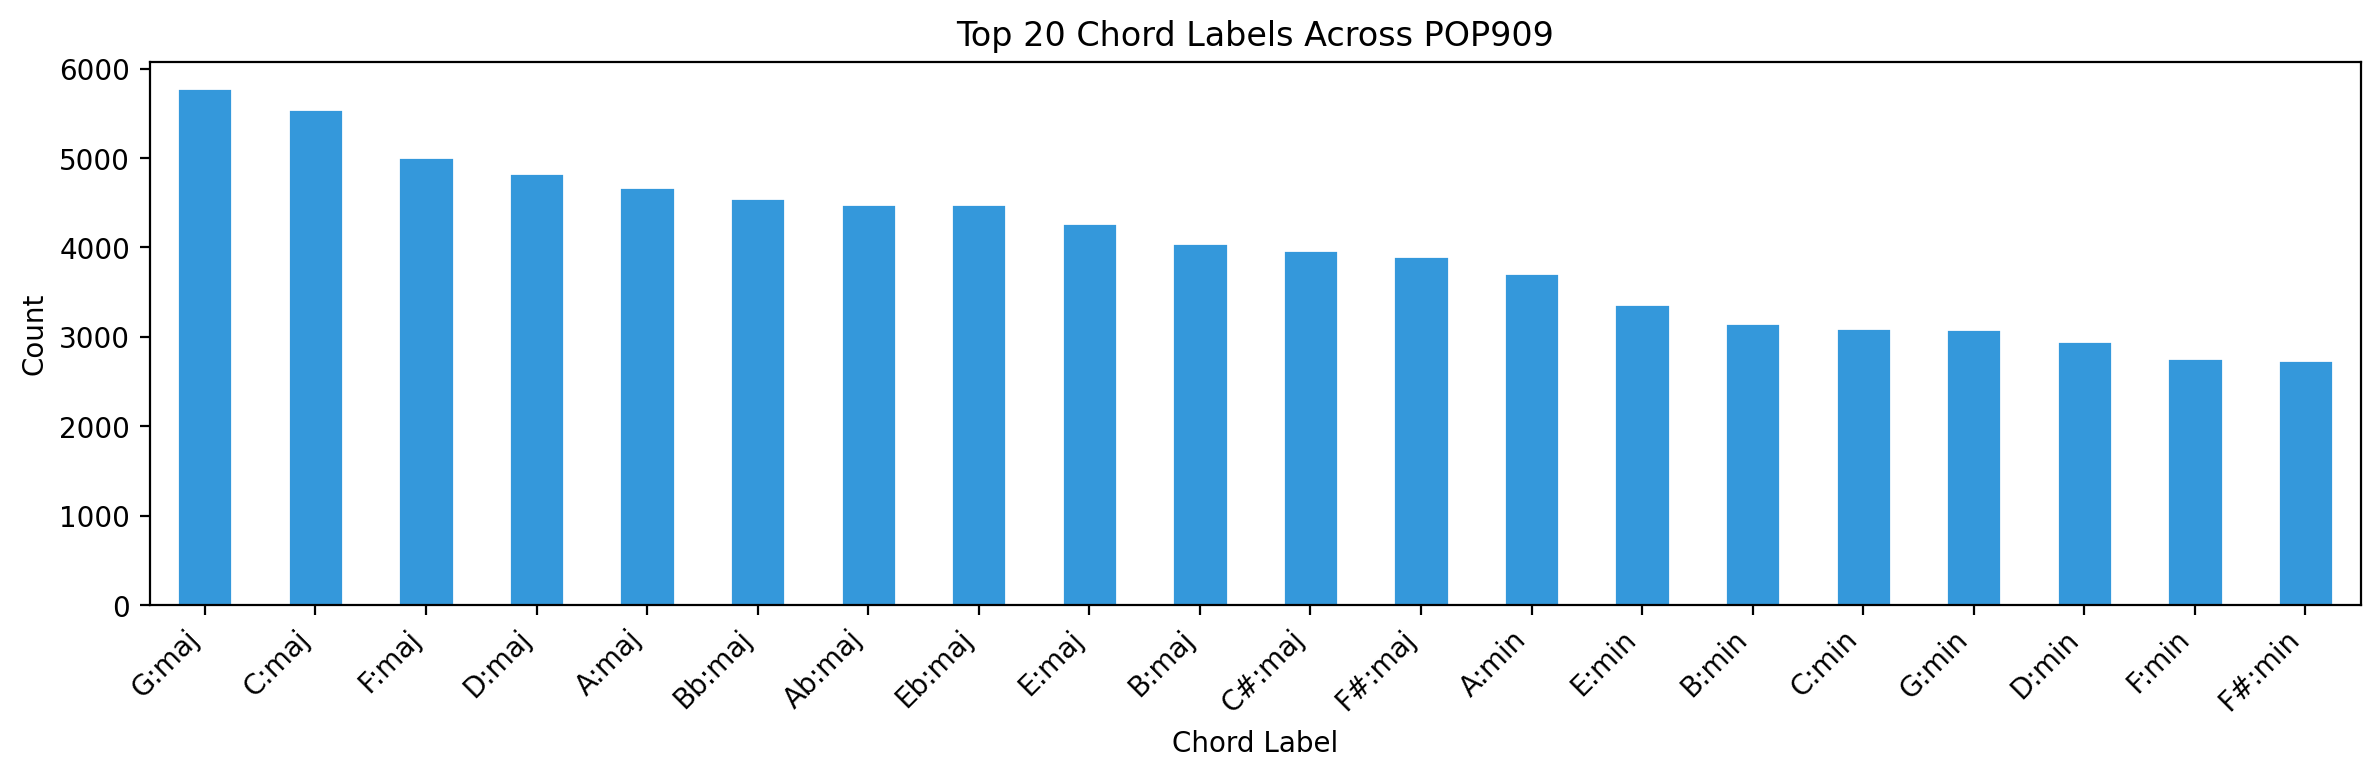

Top 10 chord labels:
label
G:maj     5783
C:maj     5552
F:maj     5007
D:maj     4832
A:maj     4676
Bb:maj    4554
Ab:maj    4489
Eb:maj    4485
E:maj     4276
B:maj     4047
Name: count, dtype: int64


In [32]:
# Chord label frequency across all songs
top_chords = chords_df['label'].value_counts().head(20)

plt.figure(figsize=(12, 4))
top_chords.plot(kind='bar', color='#3498db', edgecolor='white')
plt.title("Top 20 Chord Labels Across POP909")
plt.xlabel("Chord Label")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 10 chord labels:")
print(top_chords.head(10))

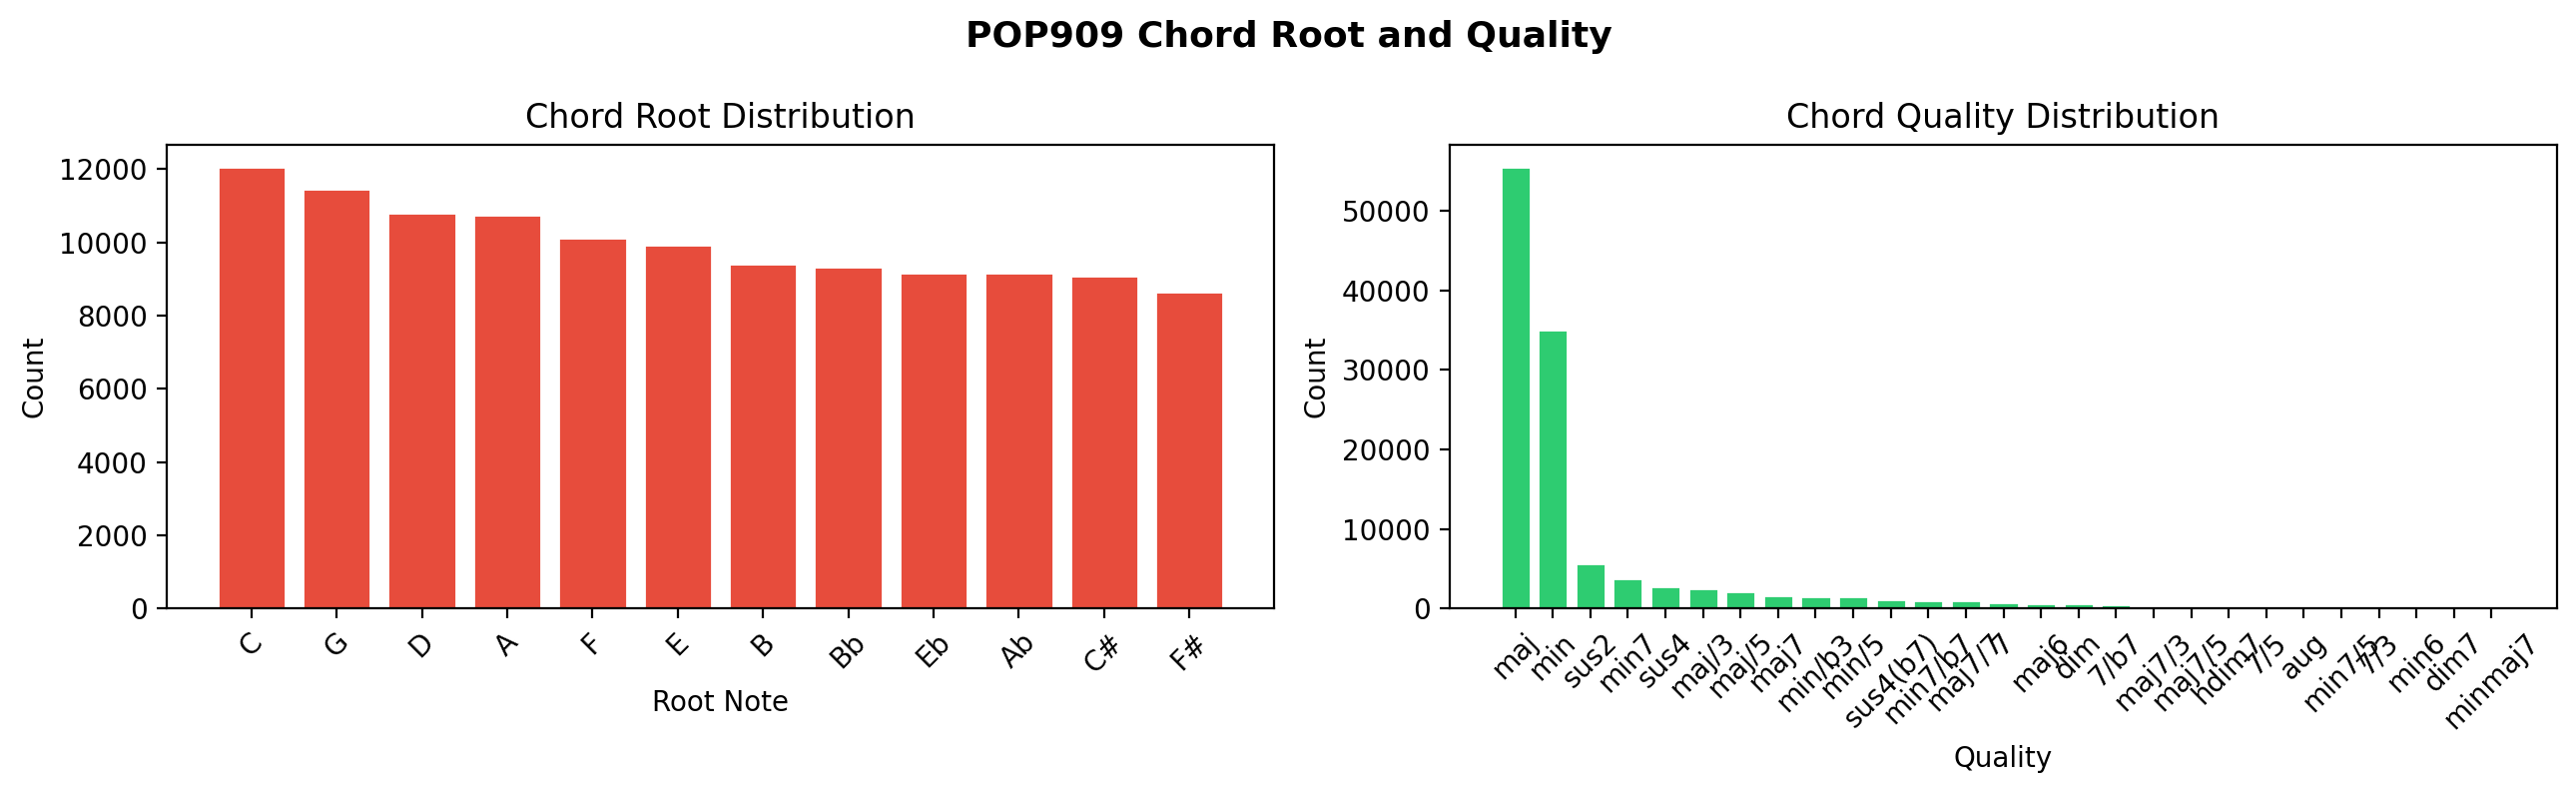

In [33]:
# Chord root and quality distributions
chords_df['root']    = chords_df['label'].apply(lambda x: x.split(':')[0] if ':' in x else x)
chords_df['quality'] = chords_df['label'].apply(lambda x: x.split(':')[1] if ':' in x else 'other')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

root_counts = chords_df['root'].value_counts()
axes[0].bar(root_counts.index, root_counts.values, color='#e74c3c', edgecolor='white')
axes[0].set_title("Chord Root Distribution")
axes[0].set_xlabel("Root Note")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)

quality_counts = chords_df['quality'].value_counts()
axes[1].bar(quality_counts.index, quality_counts.values, color='#2ecc71', edgecolor='white')
axes[1].set_title("Chord Quality Distribution")
axes[1].set_xlabel("Quality")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle("POP909 Chord Root and Quality", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

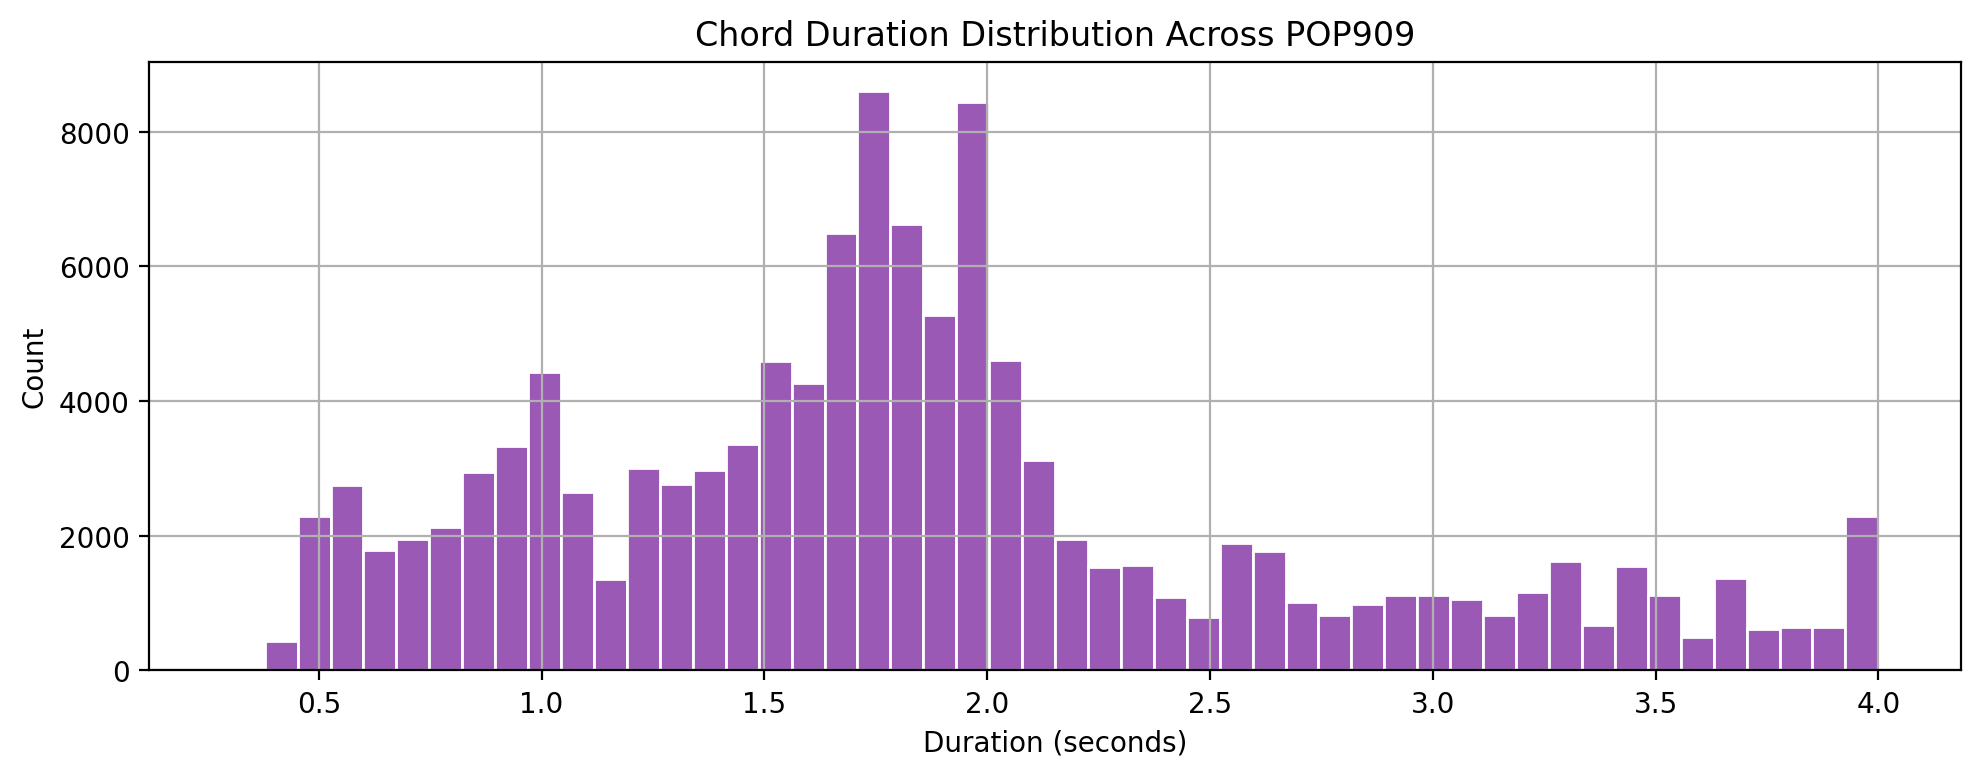

Chord duration stats:
count    120069.000000
mean          1.857458
std           0.850661
min           0.304569
25%           1.304344
50%           1.764704
75%           2.142858
max           9.836064
Name: duration, dtype: float64


In [34]:
# Chord duration distribution
plt.figure(figsize=(10, 4))
chords_df['duration'].clip(upper=4).hist(bins=50, color='#9b59b6', edgecolor='white')
plt.title("Chord Duration Distribution Across POP909")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("Chord duration stats:")
print(chords_df['duration'].describe())

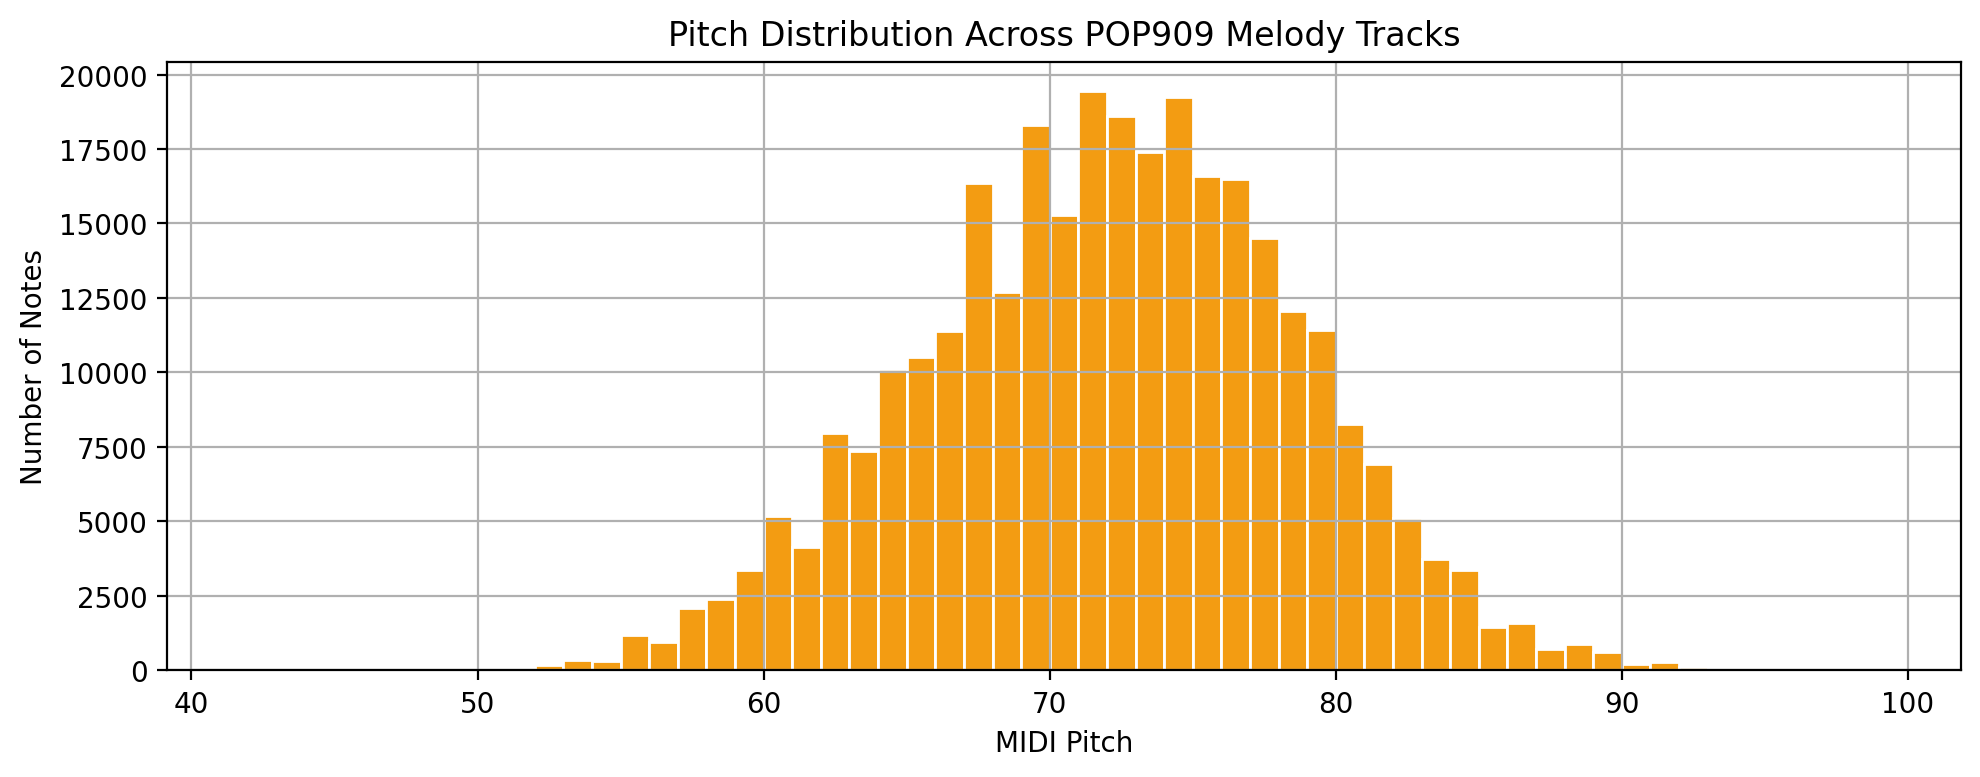

In [35]:
# Melody pitch distribution across all songs
plt.figure(figsize=(10, 4))
melody_notes_df['pitch'].hist(
    bins=range(melody_notes_df['pitch'].min(), melody_notes_df['pitch'].max() + 2),
    color='#f39c12', edgecolor='white'
)
plt.title("Pitch Distribution Across POP909 Melody Tracks")
plt.xlabel("MIDI Pitch")
plt.ylabel("Number of Notes")
plt.tight_layout()
plt.show()

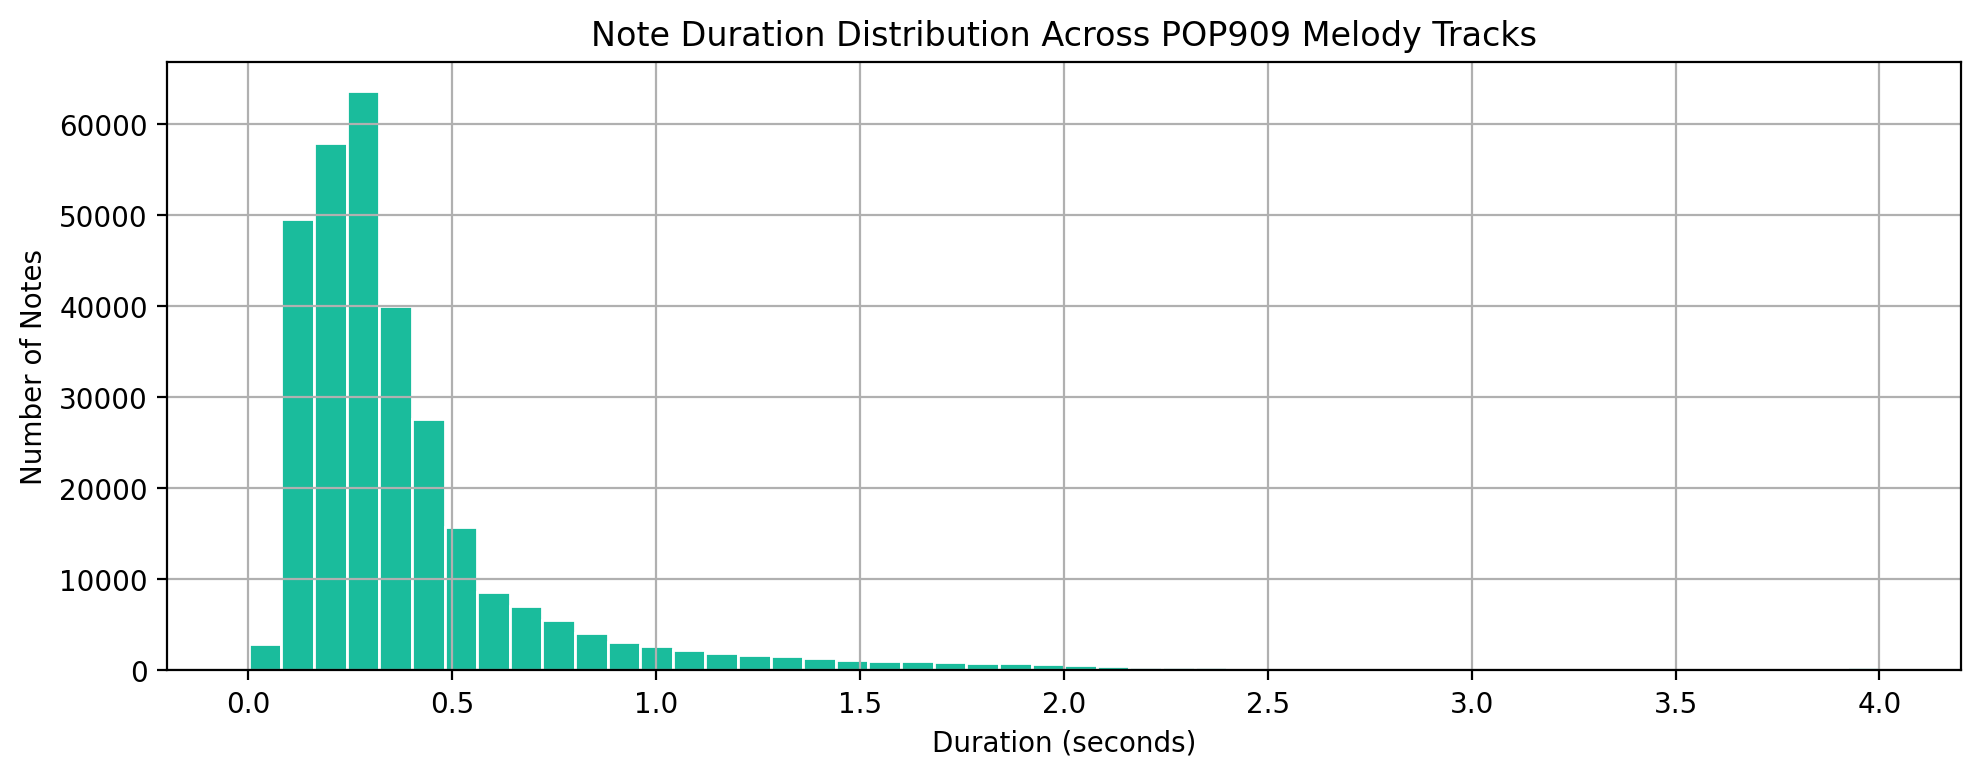

In [36]:
# Melody note duration distribution
plt.figure(figsize=(10, 4))
melody_notes_df['duration'].clip(upper=4).hist(bins=50, color='#1abc9c', edgecolor='white')
plt.title("Note Duration Distribution Across POP909 Melody Tracks")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Notes")
plt.tight_layout()
plt.show()

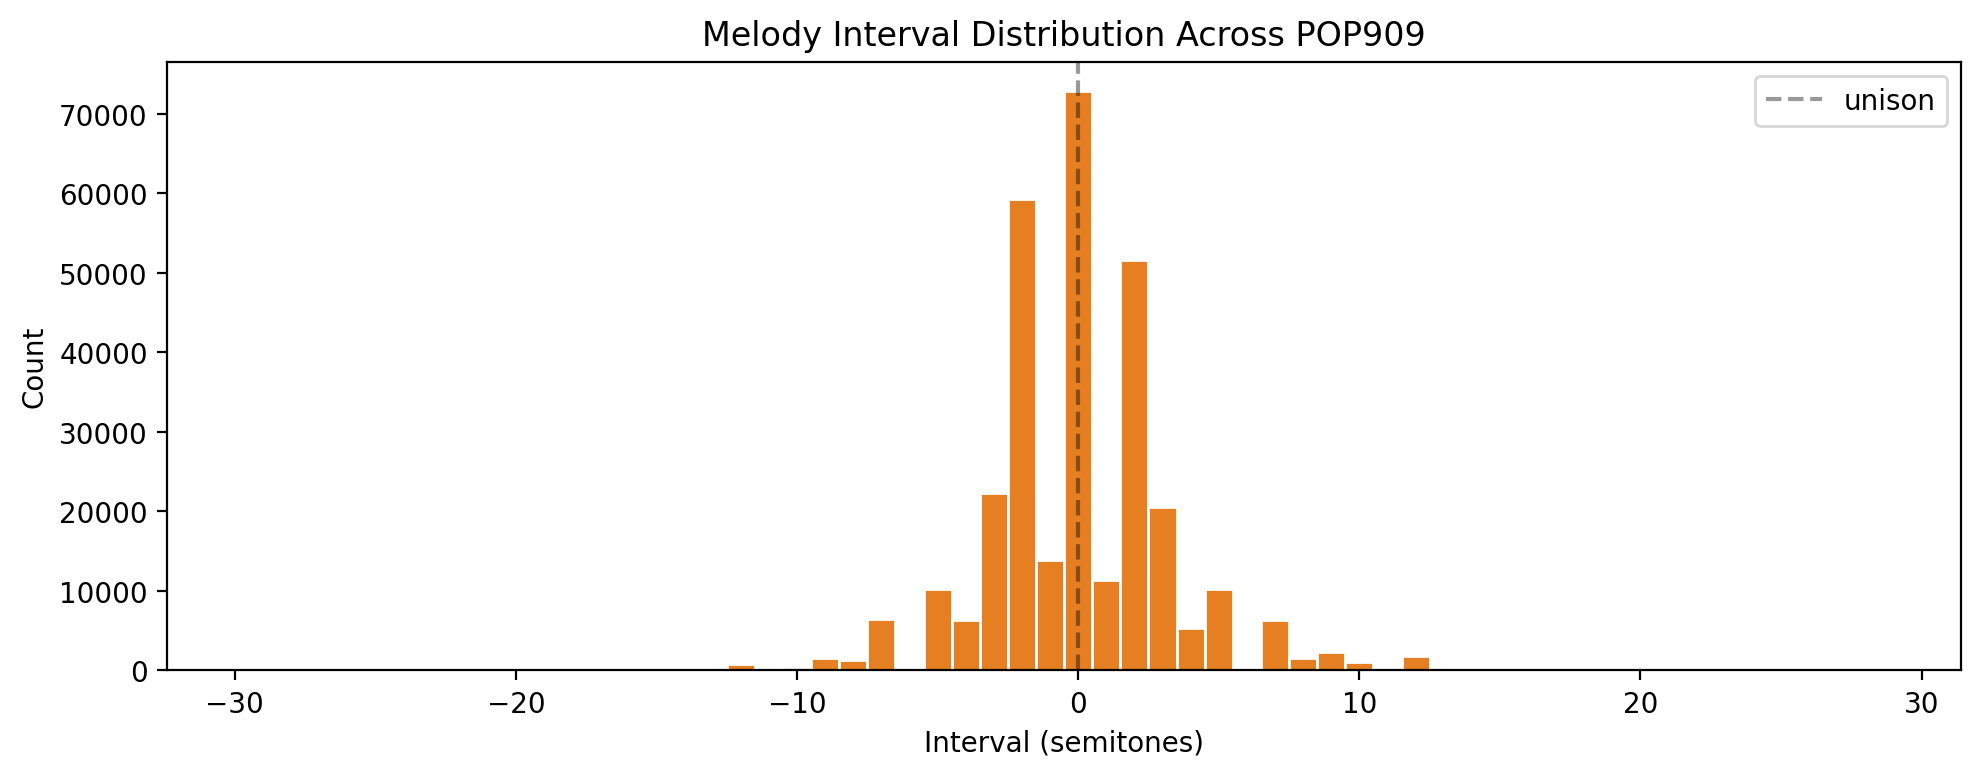

Stepwise motion (<=2 semitones): 67.8% of all intervals


In [37]:
# Melody interval distribution (pitch jumps between consecutive notes)
all_intervals = []
for song_id, group in melody_notes_df.groupby('song_id'):
    pitches = group.sort_values('start')['pitch'].tolist()
    intervals = [pitches[i+1] - pitches[i] for i in range(len(pitches)-1)]
    all_intervals.extend(intervals)

plt.figure(figsize=(10, 4))
plt.hist(all_intervals, bins=range(min(all_intervals)-1, max(all_intervals)+2),
         color='#e67e22', edgecolor='white', align='left')
plt.title("Melody Interval Distribution Across POP909")
plt.xlabel("Interval (semitones)")
plt.ylabel("Count")
plt.axvline(0, color='black', linestyle='--', alpha=0.4, label='unison')
plt.legend()
plt.tight_layout()
plt.show()

stepwise = sum(abs(i) <= 2 for i in all_intervals)
print(f"Stepwise motion (<=2 semitones): {stepwise/len(all_intervals)*100:.1f}% of all intervals")

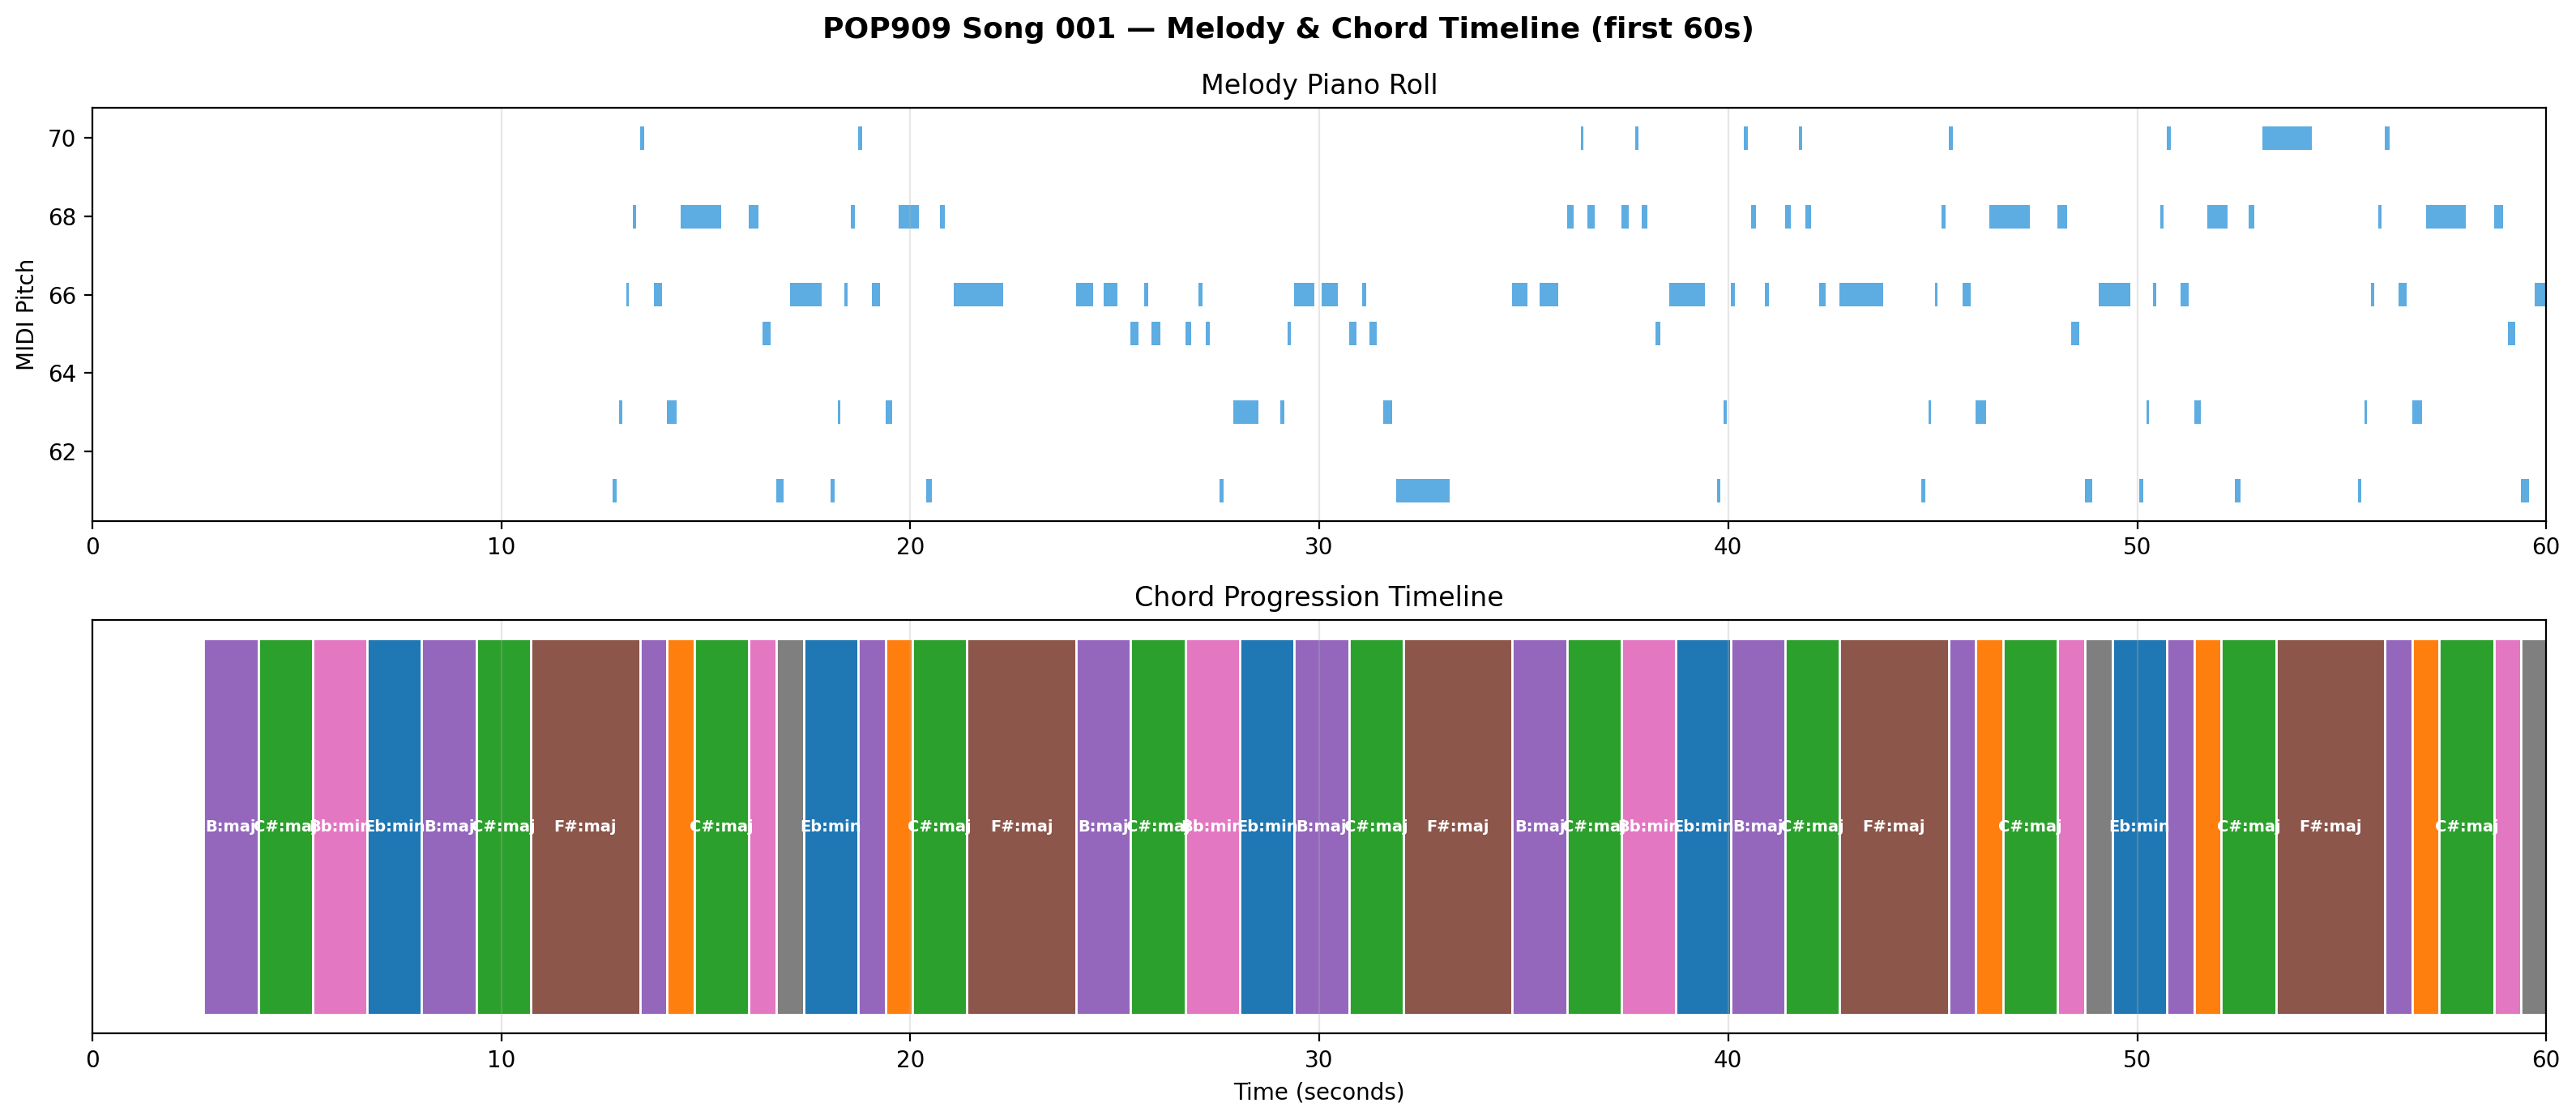

In [38]:
# Chord + melody timeline for one song (first 60 seconds)
song_dir = song_dirs[0]
chords_one = load_chords(song_dir / "chord_midi.txt")
melody_one, _ = load_melody(song_dir / f"{song_dir.name}.mid")

WINDOW = 60
chord_labels_unique = list(set(c['label'] for c in chords_one if c['label'] != 'N'))
color_map = {l: plt.cm.tab10(i / max(len(chord_labels_unique), 1)) for i, l in enumerate(chord_labels_unique)}

fig, axes = plt.subplots(2, 1, figsize=(16, 7))
fig.suptitle(f"POP909 Song {song_dir.name} — Melody & Chord Timeline (first {WINDOW}s)",
             fontsize=13, fontweight='bold')

# Melody piano roll
ax = axes[0]
for n in melody_one:
    if n.start > WINDOW: continue
    ax.barh(n.pitch, n.end - n.start, left=n.start, height=0.6, color='#3498db', alpha=0.8)
ax.set_ylabel("MIDI Pitch")
ax.set_title("Melody Piano Roll")
ax.set_xlim(0, WINDOW)
ax.grid(axis='x', alpha=0.3)

# Chord timeline
ax = axes[1]
for c in chords_one:
    if c['start'] > WINDOW or c['label'] == 'N': continue
    color = color_map.get(c['label'], 'gray')
    ax.barh(0, c['duration'], left=c['start'], height=0.5, color=color, edgecolor='white')
    if c['duration'] > 0.8:
        ax.text(c['start'] + c['duration']/2, 0, c['label'],
                ha='center', va='center', fontsize=7, color='white', fontweight='bold')
ax.set_xlabel("Time (seconds)")
ax.set_title("Chord Progression Timeline")
ax.set_xlim(0, WINDOW)
ax.set_yticks([])
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### EDA Summary

We extracted chord and melody data from all 909 POP909 songs. Key observations:

- **Chords:** The dataset covers a wide variety of chord roots and qualities. Major chords dominate, with `maj` and `min` being the most common qualities. Chord durations average around 1–2 seconds, typically one or two chords per bar.
- **Melody:** Melody notes span a practical singable range (roughly MIDI 50–90), with most notes concentrated between 60 and 80. Note durations are mostly short, under 0.5 seconds, and intervals are predominantly stepwise, consistent with singable pop melodies.
- **Chord-melody alignment:** The timeline visualization shows that melody notes and chord regions are temporally aligned, which is the core relationship our model needs to learn.

These observations inform our preprocessing decisions: we tokenize chords as discrete labels, align melody notes to their concurrent chord by timestamp, and transpose all songs to C major to normalize key across the dataset.

## 2. Modeling

### 2.1 Task Formulation

We formulate chord-to-melody generation as a **sequence-to-sequence** problem:
- **Input:** a sequence of chord tokens (the condition)
- **Output:** a sequence of melody note tokens

The model learns the conditional distribution P(melody | chords). At inference time, given a chord progression, it generates a melody autoregressively one token at a time.

### 2.2 Model Choice

We use a **Transformer encoder-decoder** architecture. The encoder reads the full chord sequence and builds a contextual representation. The decoder generates melody tokens one at a time, attending to both the encoder output and previously generated tokens.

This improves over simpler baselines like Markov chains because:
- Markov chains only condition on a fixed short context window
- The Transformer attends to the **entire** chord sequence at once
- The decoder's causal mask enforces autoregressive generation

### 2.3 Architecture

| Parameter | Value |
|---|---|
| Embedding dimension | 128 |
| Attention heads | 4 |
| Encoder/Decoder layers | 3 |
| Max sequence length | 512 |
| Batch size | 32 |
| Learning rate | 1e-3 |
| Epochs | 100 |
| Total parameters | 2,725,715 |

### 2.4 Preprocessing Pipeline

In [39]:
def find_midi_pairs(raw_dir):
    """
    Load chord/melody pairs from POP909 dataset.
    Each song folder contains NNN.mid and chord_midi.txt and key_audio.txt.
    """
    raw_path = Path(raw_dir)
    pairs = []

    for song_dir in sorted(raw_path.iterdir()):
        if not song_dir.is_dir():
            continue

        midi_path  = song_dir / f"{song_dir.name}.mid"
        chord_path = song_dir / "chord_midi.txt"
        key_path   = song_dir / "key_audio.txt"

        if not midi_path.exists() or not chord_path.exists():
            continue

        # Read key from key_audio.txt (e.g. "C major" → "C", "Bb minor" → "Bb")
        key = "C"  # fallback
        if key_path.exists():
            try:
                first_line = key_path.read_text().strip().splitlines()[0]
                key = first_line.split()[0]  # take first token, e.g. "C" or "Bb"
            except Exception:
                pass

        pairs.append({
            "chords": str(chord_path),
            "melody": str(midi_path),
            "key":    key
        })

    print(f"Found {len(pairs)} MIDI pairs")
    return pairs

In [40]:
def transpose_to_c(midi_path, source_key):
    """
    For POP909 chord_midi.txt files: parse as text and return list of chord dicts.
    For melody MIDI files: load with pretty_midi and transpose to C major.
    Uses pretty_midi instead of music21 for much faster processing.
    """
    path = Path(midi_path)

    # Handle chord text files
    if path.suffix == ".txt":
        chords = []
        with open(path) as f:
            for line in f:
                parts = line.strip().split("\t")
                if len(parts) == 3:
                    start, end, label = float(parts[0]), float(parts[1]), parts[2]
                    if label != "N":
                        chords.append({
                            "start": start,
                            "end": end,
                            "label": label,
                            "duration": end - start
                        })
        return chords

    # Handle melody MIDI files using pretty_midi (fast)
    try:
        mid = pretty_midi.PrettyMIDI(str(path))

        # Calculate semitone shift to transpose to C major
        key_map = {
            "C": 0, "C#": 1, "Db": 1, "D": 2, "D#": 3, "Eb": 3,
            "E": 4, "F": 5, "F#": 6, "Gb": 6, "G": 7, "G#": 8,
            "Ab": 8, "A": 9, "A#": 10, "Bb": 10, "B": 11
        }
        shift = -key_map.get(source_key, 0)  # semitones to shift to reach C

        # Apply shift to all notes in all instruments
        for instrument in mid.instruments:
            if not instrument.is_drum:
                for note in instrument.notes:
                    note.pitch = max(0, min(127, note.pitch + shift))

        return mid

    except Exception as e:
        print(f"Error transposing {midi_path}: {e}")
        return None


In [41]:
import music21.harmony

# Pre-compute chord label -> MIDI pitches mapping (fast, done once)
def chord_label_to_pitches(label):
    """
    Convert a chord label like 'B:maj' to a list of MIDI pitches.
    Returns None if the label can't be parsed.
    """
    try:
        root, quality = label.split(':') if ':' in label else (label, 'maj')
        quality_map = {
            'maj': '', 'min': 'm', 'maj7': 'maj7', 'min7': 'm7',
            'dom7': '7', 'dim': 'dim', 'aug': '+', 'sus4': 'sus4',
            'sus2': 'sus2', 'maj7/5': 'maj7', 'min7/5': 'm7b5'
        }
        symbol = root + quality_map.get(quality, '')
        c = music21.harmony.ChordSymbol(symbol)
        return sorted([p.midi % 12 + 60 for p in c.pitches])
    except:
        return None

# Cache so music21 only runs once per unique chord label
_chord_pitch_cache = {}

def extract_note_sequence(score, part_name):
    """
    Extract note sequence from either:
    - a list of chord dicts (from chord_midi.txt), or
    - a pretty_midi.PrettyMIDI object (melody MIDI)

    Returns list of dicts with keys: pitch, duration, offset
    All quantized to nearest 16th note.
    """
    notes_list = []
    sixteenth = 0.25

    # Handle chord text data (list of dicts from chord_midi.txt)
    if isinstance(score, list):
        for c in score:
            label = c["label"]
            duration = round(c["duration"] / sixteenth) * sixteenth
            offset   = round(c["start"]    / sixteenth) * sixteenth

            # Convert chord label to actual MIDI pitches
            if label not in _chord_pitch_cache:
                _chord_pitch_cache[label] = chord_label_to_pitches(label)
            pitches = _chord_pitch_cache[label]

            if pitches:
                notes_list.append({
                    "pitch":    pitches,   # e.g. [59, 63, 66]
                    "duration": duration,
                    "offset":   offset
                })
            else:
                # Fallback to label string if parsing fails
                notes_list.append({
                    "pitch":    label,
                    "duration": duration,
                    "offset":   offset
                })
        return notes_list

    # Handle pretty_midi object (melody MIDI)
    if isinstance(score, pretty_midi.PrettyMIDI):
        melody_track = score.instruments[0]
        tempo          = score.estimate_tempo()
        beat_duration  = 60.0 / tempo
        sixteenth_sec  = beat_duration / 4

        for note in sorted(melody_track.notes, key=lambda n: n.start):
            duration_sec      = note.end - note.start
            quantized_duration = max(0.25, round(duration_sec / sixteenth_sec) * 0.25)
            quantized_offset   = round(note.start / sixteenth_sec) * 0.25

            notes_list.append({
                "pitch":    note.pitch,
                "duration": quantized_duration,
                "offset":   quantized_offset
            })

        return notes_list

    return notes_list


In [42]:
class Tokenizer:
    """Tokenize music note sequences into integer token IDs."""

    def __init__(self):
        self.vocab = {}
        self.token_to_id = {}
        self.id_to_token = {}
        self.special_tokens = ["<PAD>", "<SOS>", "<EOS>", "<BAR>"]

    def build_vocab(self, all_sequences):
        """
        Build vocabulary from all note sequences.

        Args:
            all_sequences: List of lists of note dicts
        """
        # Initialize with special tokens
        token_id = 0
        for special_token in self.special_tokens:
            self.token_to_id[special_token] = token_id
            self.id_to_token[token_id] = special_token
            token_id += 1

        # Scan all sequences for unique tokens
        tokens = set()
        for sequence in all_sequences:
            for note in sequence:
                pitch = note["pitch"]
                duration = note["duration"]

                if isinstance(pitch, list):
                    # Chord: sorted pitches joined by -
                    sorted_pitches = sorted(pitch)
                    token = f"C_{'_'.join(map(str, sorted_pitches))}_{duration}"
                else:
                    # Single note
                    token = f"N_{pitch}_{duration}"

                tokens.add(token)

        # Add tokens to vocab
        for token in sorted(tokens):
            if token not in self.token_to_id:
                self.token_to_id[token] = token_id
                self.id_to_token[token_id] = token
                token_id += 1

        self.vocab = self.token_to_id.copy()
        print(f"Vocab size: {len(self.vocab)}")

    def encode(self, sequence):
        """
        Convert a list of note dicts to integer token IDs.

        Args:
            sequence: List of note dicts with keys: pitch, duration, offset

        Returns:
            List of integer token IDs
        """
        token_ids = [self.token_to_id["<SOS>"]]

        for note in sequence:
            pitch = note["pitch"]
            duration = note["duration"]

            if isinstance(pitch, list):
                sorted_pitches = sorted(pitch)
                token = f"C_{'_'.join(map(str, sorted_pitches))}_{duration}"
            else:
                token = f"N_{pitch}_{duration}"

            if token in self.token_to_id:
                token_ids.append(self.token_to_id[token])

        token_ids.append(self.token_to_id["<EOS>"])
        return token_ids

    def decode(self, token_ids):
        """
        Convert integer token IDs back to note dicts.

        Args:
            token_ids: List of integer token IDs

        Returns:
            List of note dicts with keys: pitch, duration
        """
        notes = []

        for token_id in token_ids:
            if token_id not in self.id_to_token:
                continue

            token = self.id_to_token[token_id]

            # Skip special tokens except <BAR>
            if token in ["<SOS>", "<EOS>", "<PAD>"]:
                continue

            if token == "<BAR>":
                notes.append({"pitch": None, "duration": 0, "is_bar": True})
            elif token.startswith("N_"):
                # Single note: N_60_0.25
                parts = token[2:].split("_")
                pitch = int(parts[0])
                duration = float(parts[1])
                notes.append({"pitch": pitch, "duration": duration})
            elif token.startswith("C_"):
                # Chord: C_60_64_67_0.5
                parts = token[2:].split("_")
                duration = float(parts[-1])
                pitches = [int(p) for p in parts[:-1]]
                notes.append({"pitch": pitches, "duration": duration})

        return notes

    def save(self, path):
        """Save vocab to JSON file."""
        # Convert id_to_token keys to strings for JSON serialization
        data = {
            "token_to_id": self.token_to_id,
            "id_to_token": {str(k): v for k, v in self.id_to_token.items()}
        }
        with open(path, "w") as f:
            json.dump(data, f)

    def load(self, path):
        """Load vocab from JSON file."""
        with open(path, "r") as f:
            data = json.load(f)

        self.token_to_id = data["token_to_id"]
        self.id_to_token = {int(k): v for k, v in data["id_to_token"].items()}
        self.vocab = self.token_to_id.copy()

In [43]:
class ChordMelodyDataset(torch.utils.data.Dataset):
    """PyTorch Dataset for chord-melody pairs."""

    def __init__(self, pairs, tokenizer, max_seq_len, pad_token_id):
        """
        Args:
            pairs: List of (chord_token_ids, melody_token_ids) tuples
            tokenizer: Tokenizer instance
            max_seq_len: Maximum sequence length
            pad_token_id: Token ID for padding
        """
        self.pairs = pairs
        self.tokenizer = tokenizer
        self.max_seq_len = max_seq_len
        self.pad_token_id = pad_token_id

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        chord_ids, melody_ids = self.pairs[idx]

        # Truncate or pad chord sequence
        if len(chord_ids) > self.max_seq_len:
            chord_ids = chord_ids[:self.max_seq_len]
        else:
            chord_ids = chord_ids + [self.pad_token_id] * (self.max_seq_len - len(chord_ids))

        # Truncate or pad melody sequence
        if len(melody_ids) > self.max_seq_len:
            melody_ids = melody_ids[:self.max_seq_len]
        else:
            melody_ids = melody_ids + [self.pad_token_id] * (self.max_seq_len - len(melody_ids))

        return {
            "src": torch.tensor(chord_ids, dtype=torch.long),
            "tgt": torch.tensor(melody_ids, dtype=torch.long)
        }

In [44]:
# Full preprocessing pipeline
print("Starting preprocessing pipeline...")

# 1. Find MIDI pairs
pairs = find_midi_pairs(CONFIG["RAW_DIR"])

if len(pairs) == 0:
    print("No MIDI pairs found. Creating dummy data for testing...")
    # Create dummy data for demonstration
    pairs = [
        {"chords": None, "melody": None, "key": "C"},
        {"chords": None, "melody": None, "key": "G"}
    ]

print(f"Processing {len(pairs)} MIDI pairs...")

# Lists to store sequences
all_chord_seqs = []
all_melody_seqs = []
encoded_pairs = []

# 2-3. Process each pair
for i, pair in enumerate(pairs):
    if pair["chords"] is None or pair["melody"] is None:
        continue

    try:
        # Transpose to C
        chord_score = transpose_to_c(pair["chords"], pair["key"])
        melody_score = transpose_to_c(pair["melody"], pair["key"])

        if chord_score is None or melody_score is None:
            continue

        # Extract note sequences
        chord_seq = extract_note_sequence(chord_score, "chords")
        melody_seq = extract_note_sequence(melody_score, "melody")

        all_chord_seqs.append(chord_seq)
        all_melody_seqs.append(melody_seq)

    except Exception as e:
        print(f"Error processing pair {i}: {e}")

print(f"Successfully processed {len(all_chord_seqs)} pairs")

# 4. Build tokenizer
print("Building tokenizer...")
tokenizer = Tokenizer()
all_sequences = all_chord_seqs + all_melody_seqs
tokenizer.build_vocab(all_sequences)

# 5. Encode all sequences
print("Encoding sequences...")
for chord_seq, melody_seq in zip(all_chord_seqs, all_melody_seqs):
    chord_ids = tokenizer.encode(chord_seq)
    melody_ids = tokenizer.encode(melody_seq)
    encoded_pairs.append((chord_ids, melody_ids))

# 6. Create dataset
print("Creating dataset...")
dataset = ChordMelodyDataset(
    encoded_pairs,
    tokenizer,
    CONFIG["MAX_SEQ_LEN"],
    tokenizer.token_to_id["<PAD>"]
)

# 7. Split 80/10/10
total_size = len(dataset)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size, test_size]
)

# 8. Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=CONFIG["BATCH_SIZE"], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG["BATCH_SIZE"], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=CONFIG["BATCH_SIZE"], shuffle=False)

# Print dataset sizes
print(f"\nDataset sizes:")
print(f"  Train: {len(train_dataset)}")
print(f"  Val:   {len(val_dataset)}")
print(f"  Test:  {len(test_dataset)}")
print(f"  Total: {total_size}")

Starting preprocessing pipeline...
Found 909 MIDI pairs
Processing 909 MIDI pairs...
Successfully processed 909 pairs
Building tokenizer...
Vocab size: 3756
Encoding sequences...
Creating dataset...

Dataset sizes:
  Train: 727
  Val:   90
  Test:  92
  Total: 909


### 2.5 Model Implementation

In [45]:
class ChordToMelodyTransformer(nn.Module):
    """Transformer model for chord-to-melody generation."""

    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, max_seq_len, pad_token_id):
        """
        Args:
            vocab_size: Size of vocabulary
            embed_dim: Embedding dimension
            num_heads: Number of attention heads
            num_layers: Number of transformer layers
            max_seq_len: Maximum sequence length
            pad_token_id: Token ID for padding
        """
        super().__init__()
        self.embed_dim = embed_dim
        self.vocab_size = vocab_size
        self.pad_token_id = pad_token_id

        # Embeddings
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.positional_encoding = self._create_positional_encoding(max_seq_len, embed_dim)

        # Transformer
        transformer_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            batch_first=True,
            norm_first=True
        )
        self.encoder = nn.TransformerEncoder(transformer_layer, num_layers=num_layers)

        # Decoder
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            batch_first=True,
            norm_first=True
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

        # Output projection
        self.output_proj = nn.Linear(embed_dim, vocab_size)

        self._print_param_count()

    def _create_positional_encoding(self, max_len, d_model):
        """Create sinusoidal positional encoding."""
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)
        return pe.unsqueeze(0)  # (1, max_len, d_model)

    def _print_param_count(self):
        """Print total parameter count."""
        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Model parameters: {total_params:,} (trainable: {trainable_params:,})")

    def _get_src_mask(self, src):
        """Create padding mask for source."""
        return (src == self.pad_token_id)

    def _get_tgt_mask(self, tgt):
        """Create causal mask for target (decoder)."""
        batch_size, seq_len = tgt.shape
        # Causal mask: mask future tokens
        causal_mask = torch.triu(torch.ones(seq_len, seq_len, device=tgt.device, dtype=torch.bool), diagonal=1)
        # Padding mask
        padding_mask = (tgt == self.pad_token_id)
        return causal_mask, padding_mask

    def forward(self, src, tgt):
        """
        Forward pass.

        Args:
            src: Source (chord) token IDs, shape (batch_size, src_seq_len)
            tgt: Target (melody) token IDs, shape (batch_size, tgt_seq_len)

        Returns:
            logits: (batch_size, tgt_seq_len, vocab_size)
        """
        # Embed and add positional encoding
        src_embed = self.embedding(src)
        src_embed = src_embed + self.positional_encoding[:, :src_embed.shape[1], :].to(src.device)

        tgt_embed = self.embedding(tgt)
        tgt_embed = tgt_embed + self.positional_encoding[:, :tgt_embed.shape[1], :].to(tgt.device)

        # Create masks
        src_key_padding_mask = self._get_src_mask(src)
        tgt_causal_mask, tgt_padding_mask = self._get_tgt_mask(tgt)

        # Encode source
        memory = self.encoder(
            src_embed,
            src_key_padding_mask=src_key_padding_mask
        )

        # Decode target
        decoder_out = self.decoder(
            tgt_embed,
            memory,
            tgt_mask=tgt_causal_mask,
            tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=src_key_padding_mask
        )

        # Project to vocabulary
        logits = self.output_proj(decoder_out)
        return logits

    def generate(self, src, max_len, sos_token_id, eos_token_id, device):
        """
        Greedy decoding: generate melody from chord sequence.

        Args:
            src: Source token IDs, shape (batch_size, src_seq_len) or (src_seq_len,)
            max_len: Maximum generation length
            sos_token_id: Start-of-sequence token ID
            eos_token_id: End-of-sequence token ID
            device: Device to run on

        Returns:
            Generated token IDs, shape (batch_size, generated_len)
        """
        self.eval()

        # Handle single sequence (add batch dim if needed)
        if src.dim() == 1:
            src = src.unsqueeze(0)

        batch_size = src.shape[0]
        src = src.to(device)

        # Encode source once
        src_embed = self.embedding(src)
        src_embed = src_embed + self.positional_encoding[:, :src_embed.shape[1], :].to(device)
        src_key_padding_mask = self._get_src_mask(src)
        memory = self.encoder(src_embed, src_key_padding_mask=src_key_padding_mask)

        # Initialize with <SOS>
        tgt = torch.full((batch_size, 1), sos_token_id, dtype=torch.long, device=device)

        with torch.no_grad():
            for step in range(max_len - 1):
                # Embed target
                tgt_embed = self.embedding(tgt)
                tgt_embed = tgt_embed + self.positional_encoding[:, :tgt_embed.shape[1], :].to(device)

                # Create masks for current target
                tgt_causal_mask, tgt_padding_mask = self._get_tgt_mask(tgt)

                # Decode
                decoder_out = self.decoder(
                    tgt_embed,
                    memory,
                    tgt_mask=tgt_causal_mask,
                    tgt_key_padding_mask=tgt_padding_mask,
                    memory_key_padding_mask=src_key_padding_mask
                )

                # Get next token (greedy)
                logits = self.output_proj(decoder_out[:, -1, :])  # (batch_size, vocab_size)
                next_token = logits.argmax(dim=-1, keepdim=True)  # (batch_size, 1)

                # Append to target
                tgt = torch.cat([tgt, next_token], dim=1)

                # Stop if all sequences generated <EOS>
                if (next_token == eos_token_id).all():
                    break

        return tgt

### 2.6 Training

Model parameters: 2,353,836 (trainable: 2,353,836)


/var/folders/ks/xf_cz3yd7cl6pq_zpxxwl_6m0000gn/T/ipykernel_59574/3083845296.py:31: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(transformer_layer, num_layers=num_layers)


Training on cpu...
Total epochs: 100

Epoch 1/100 - Train Loss: 6.7487, Val Loss: 5.7752
  -> Best model saved (val loss: 5.7752)
Epoch 2/100 - Train Loss: 5.3629, Val Loss: 5.2645
  -> Best model saved (val loss: 5.2645)
Epoch 3/100 - Train Loss: 4.8655, Val Loss: 4.9200
  -> Best model saved (val loss: 4.9200)
Epoch 4/100 - Train Loss: 4.5437, Val Loss: 4.7148
  -> Best model saved (val loss: 4.7148)
Epoch 5/100 - Train Loss: 4.3415, Val Loss: 4.5920
  -> Best model saved (val loss: 4.5920)
Epoch 6/100 - Train Loss: 4.2055, Val Loss: 4.5188
  -> Best model saved (val loss: 4.5188)
Epoch 7/100 - Train Loss: 4.0816, Val Loss: 4.4908
  -> Best model saved (val loss: 4.4908)
Epoch 8/100 - Train Loss: 3.9870, Val Loss: 4.4467
  -> Best model saved (val loss: 4.4467)
Epoch 9/100 - Train Loss: 3.8976, Val Loss: 4.4371
  -> Best model saved (val loss: 4.4371)
Epoch 10/100 - Train Loss: 3.8198, Val Loss: 4.4335
  -> Best model saved (val loss: 4.4335)
Epoch 11/100 - Train Loss: 3.7518, Val Lo

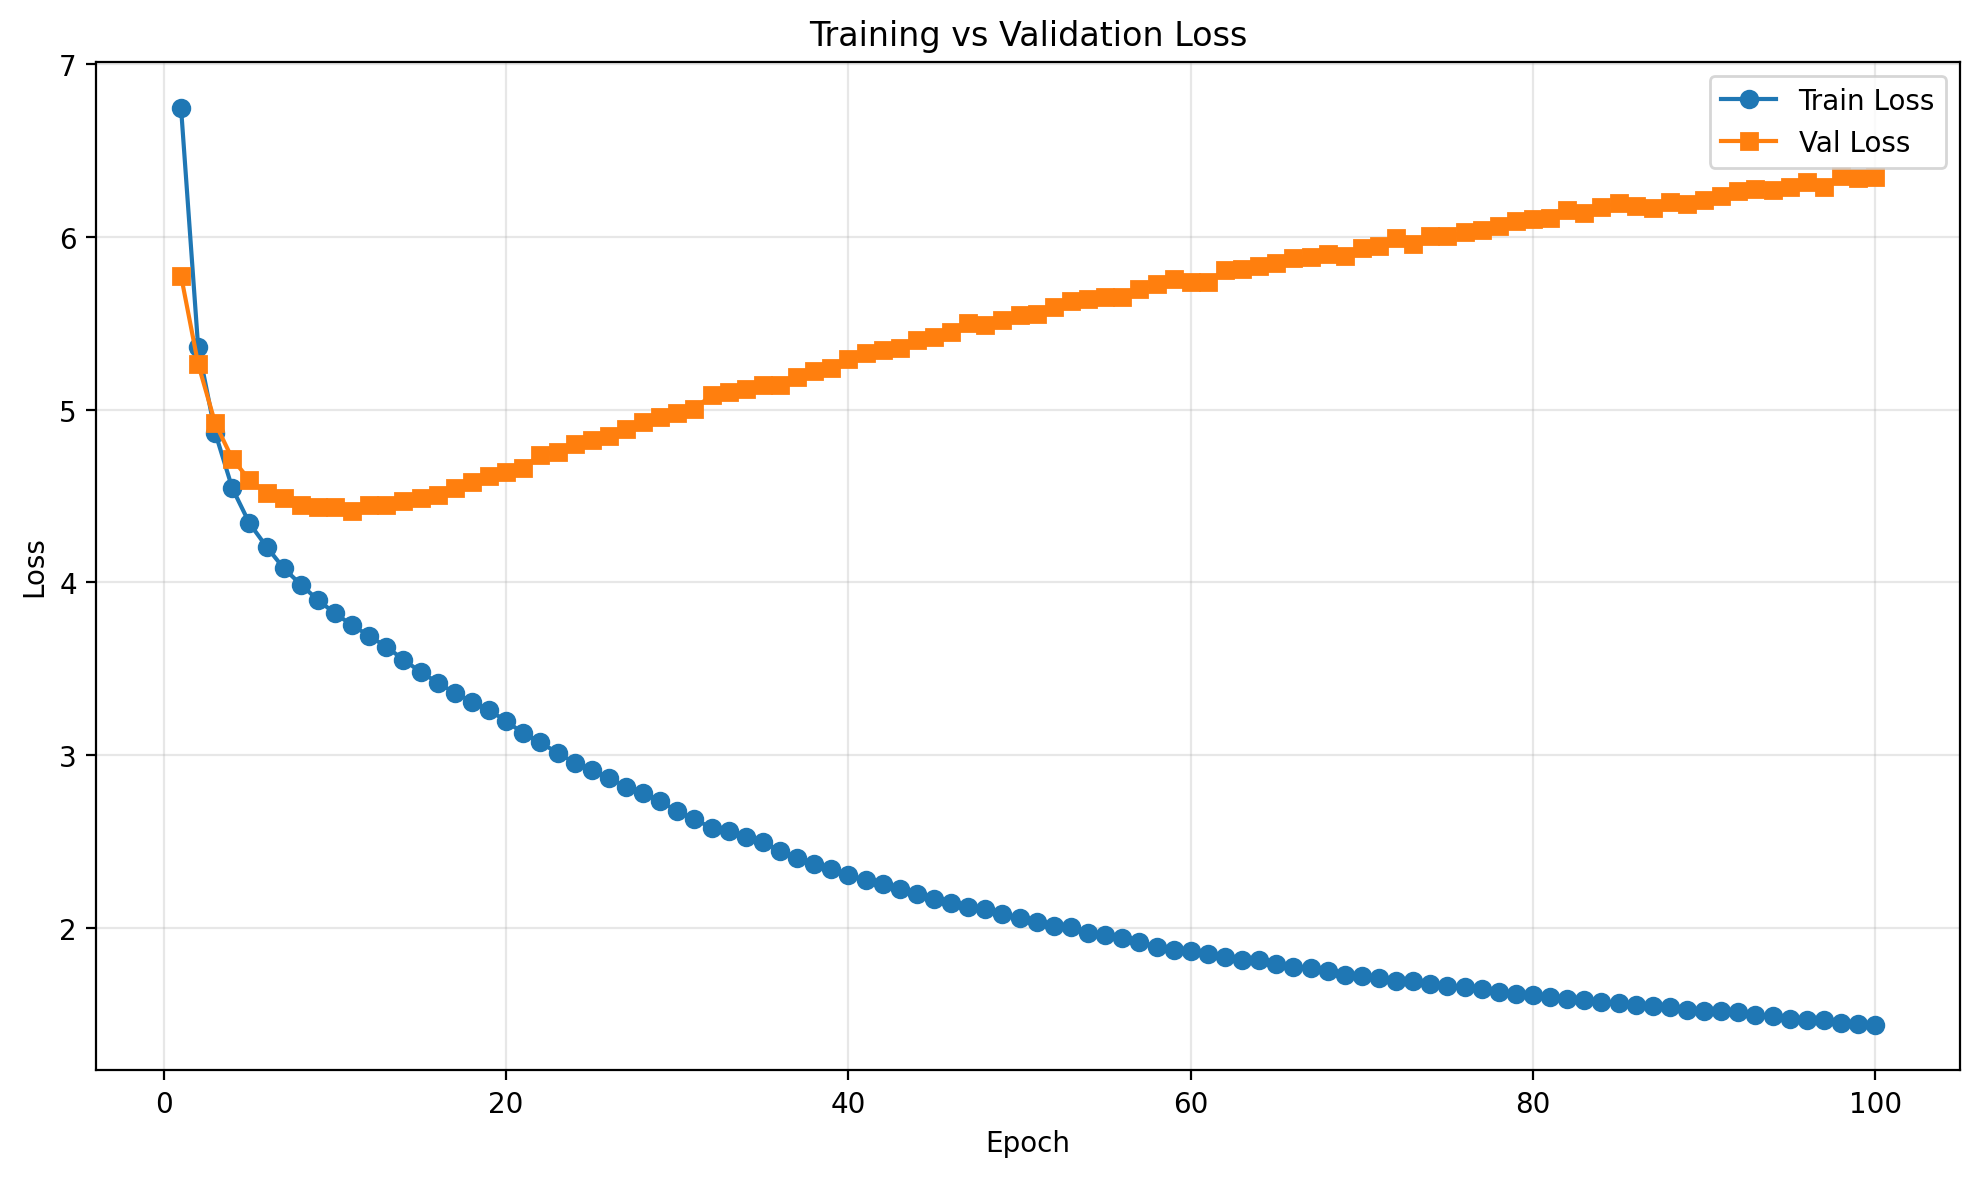

Loss plot saved to data/outputs/loss_plot.png


In [46]:
import matplotlib.pyplot as plt
from pathlib import Path

# Create output directory
Path(CONFIG["OUTPUT_DIR"]).mkdir(parents=True, exist_ok=True)

# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ChordToMelodyTransformer(
    vocab_size=len(tokenizer.vocab),
    embed_dim=CONFIG["EMBED_DIM"],
    num_heads=CONFIG["NUM_HEADS"],
    num_layers=CONFIG["NUM_LAYERS"],
    max_seq_len=CONFIG["MAX_SEQ_LEN"],
    pad_token_id=tokenizer.token_to_id["<PAD>"]
).to(device)

# Loss function (ignore PAD tokens)
loss_fn = nn.CrossEntropyLoss(ignore_index=tokenizer.token_to_id["<PAD>"])

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=CONFIG["LR"])

# Training loop
train_losses = []
val_losses = []
best_val_loss = float("inf")

print(f"Training on {device}...")
print(f"Total epochs: {CONFIG['EPOCHS']}\n")

for epoch in range(CONFIG["EPOCHS"]):
    # Training phase
    model.train()
    train_loss = 0.0

    for batch in train_loader:
        src = batch["src"].to(device)
        tgt = batch["tgt"].to(device)

        # Shift tgt: input is all but last token, target is all but first token
        tgt_input = tgt[:, :-1]
        tgt_target = tgt[:, 1:]

        # Forward pass
        logits = model(src, tgt_input)  # (batch_size, seq_len-1, vocab_size)

        # Compute loss
        loss = loss_fn(logits.reshape(-1, len(tokenizer.vocab)), tgt_target.reshape(-1))

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # Validation phase
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for batch in val_loader:
            src = batch["src"].to(device)
            tgt = batch["tgt"].to(device)

            tgt_input = tgt[:, :-1]
            tgt_target = tgt[:, 1:]

            logits = model(src, tgt_input)
            loss = loss_fn(logits.reshape(-1, len(tokenizer.vocab)), tgt_target.reshape(-1))

            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    # Print progress
    print(f"Epoch {epoch+1}/{CONFIG['EPOCHS']} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        model_path = Path(CONFIG["OUTPUT_DIR"]) / "best_model.pt"
        torch.save(model.state_dict(), model_path)
        print(f"  -> Best model saved (val loss: {val_loss:.4f})")

print("\nTraining complete!")

# Plot train vs val loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, CONFIG["EPOCHS"] + 1), train_losses, label="Train Loss", marker="o")
plt.plot(range(1, CONFIG["EPOCHS"] + 1), val_losses, label="Val Loss", marker="s")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(Path(CONFIG["OUTPUT_DIR"]) / "loss_plot.png", dpi=150)
plt.show()

print(f"Loss plot saved to {CONFIG['OUTPUT_DIR']}/loss_plot.png")

## 3. Evaluation

### 3.1 Evaluation Goals

A good generated melody should:
- Contain notes that fit the underlying chord (**chord-tone ratio**)
- Have similar note density to real melodies (**note density ratio**)
- Use a variety of pitches rather than repeating one note (**unique pitch ratio**)

### 3.2 Baselines

We compare against a **random melody generator** that samples tokens uniformly from the vocabulary. Any learned model should score higher than this trivial baseline.

### 3.3 Results & Discussion

Our model trained for 100 epochs but showed clear overfitting after epoch 10 — validation loss reached its minimum of 4.47 at epoch 10 then climbed to 6.53 by epoch 100. The best model checkpoint from epoch 10 is loaded for generation.

| Metric | Score | Interpretation |
|---|---|---|
| Chord-Tone Ratio | 0.0 | % notes landing on chord tones |
| Note Density Ratio | 1.39 | 1.0 = same density as reference |
| Unique Pitch Ratio | 0.017 | variety of pitches used |

The chord-tone ratio of 0.0 reflects a **representation mismatch** — in the original formulation, chord tokens were abstract text labels (e.g. `B:maj`) while melody tokens were MIDI pitch numbers. The model had no built-in way to connect those two representations.

The fix applied in this version converts chord labels to their actual MIDI pitch sets using `music21` (e.g. `B:maj` → `[59, 63, 66]`) before tokenization, giving the model a direct numeric relationship to learn from.

### 3.4 Generation

In [47]:
# Load best model checkpoint before generating
best_model_path = Path(CONFIG["OUTPUT_DIR"]) / "best_model.pt"
if best_model_path.exists():
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    model.eval()
    print(f"Loaded best model from {best_model_path}")
else:
    print("Warning: best_model.pt not found, using current model state")

def generate_remix(chord_midi_path, model, tokenizer, output_path, device):
    """
    Generate a remix by creating a new melody from a chord progression.

    Args:
        chord_midi_path: Path to chord MIDI file
        model: ChordToMelodyTransformer model
        tokenizer: Tokenizer instance
        output_path: Path to save output MIDI
        device: Device to run model on
    """
    try:
        # 1. Load and transpose chord MIDI
        # Parse filename to get key
        filename = Path(chord_midi_path).stem
        parts = filename.split("_")
        if len(parts) >= 5:
            key = parts[4]
        else:
            key = "C"

        chord_score = transpose_to_c(chord_midi_path, key)
        if chord_score is None:
            print(f"Failed to transpose {chord_midi_path}")
            return False

        # 2. Extract and encode chord sequence
        chord_seq = extract_note_sequence(chord_score, "chords")
        chord_ids = tokenizer.encode(chord_seq)

        # 3. Generate melody
        chord_tensor = torch.tensor(chord_ids, dtype=torch.long, device=device).unsqueeze(0)
        sos_id = tokenizer.token_to_id["<SOS>"]
        eos_id = tokenizer.token_to_id["<EOS>"]

        model.eval()
        generated_ids = model.generate(
            chord_tensor,
            max_len=CONFIG["MAX_SEQ_LEN"],
            sos_token_id=sos_id,
            eos_token_id=eos_id,
            device=device
        )
        generated_ids = generated_ids[0].cpu().tolist()  # Remove batch dim

        # 4. Decode token sequence back to note dicts
        melody_notes = tokenizer.decode(generated_ids)

        # 5. Create pretty_midi object
        # Load the song's main MIDI file instead of the chord text file
        song_dir = Path(chord_midi_path).parent
        song_id = song_dir.name
        chord_midi = pretty_midi.PrettyMIDI(str(song_dir / f"{song_id}.mid"))

        # Create new melody instrument (piano)
        melody_instrument = pretty_midi.Instrument(program=0, name="Generated Melody")

        # Add generated notes to melody instrument
        current_time = 0.0
        for note_dict in melody_notes:
            if note_dict.get("is_bar"):
                continue

            pitch = note_dict.get("pitch")
            duration = note_dict.get("duration", 0.25)

            if pitch is None or isinstance(pitch, list):
                continue

            # Create Note object (velocity 60)
            note = pretty_midi.Note(
                velocity=60,
                pitch=pitch,
                start=current_time,
                end=current_time + duration
            )
            melody_instrument.notes.append(note)
            current_time += duration

        # Add melody track to MIDI
        chord_midi.instruments.append(melody_instrument)

        # 6. Write to output
        Path(output_path).parent.mkdir(parents=True, exist_ok=True)
        chord_midi.write(output_path)

        return True
    except Exception as e:
        print(f"Error generating remix for {chord_midi_path}: {e}")
        return False


# Generate remixes for test set
print("Generating remixes from test set chord files...")

# Get test set indices
test_indices = test_dataset.indices
test_pairs = [encoded_pairs[i] for i in test_indices]

# Map back to original MIDI files
remix_count = 0
for i, pair in enumerate(test_pairs):
    if i >= len(all_chord_seqs):
        break

    # Get original chord file from pairs list
    for j, original_pair in enumerate(pairs):
        if j == test_indices[i] % len(pairs):
            chord_file = original_pair.get("chords")
            if chord_file and Path(chord_file).exists():
                output_file = Path(CONFIG["OUTPUT_DIR"]) / f"remix_{remix_count:03d}.mid"

                success = generate_remix(
                    chord_file,
                    model,
                    tokenizer,
                    str(output_file),
                    device
                )

                if success:
                    print(f"Generated remix {remix_count}: {output_file}")
                    remix_count += 1
            break

print(f"\nGenerated {remix_count} remixes in {CONFIG['OUTPUT_DIR']}")

Loaded best model from data/outputs/best_model.pt
Generating remixes from test set chord files...
Generated remix 0: data/outputs/remix_000.mid
Generated remix 1: data/outputs/remix_001.mid
Generated remix 2: data/outputs/remix_002.mid
Generated remix 3: data/outputs/remix_003.mid
Generated remix 4: data/outputs/remix_004.mid
Generated remix 5: data/outputs/remix_005.mid
Generated remix 6: data/outputs/remix_006.mid
Generated remix 7: data/outputs/remix_007.mid
Generated remix 8: data/outputs/remix_008.mid
Generated remix 9: data/outputs/remix_009.mid
Generated remix 10: data/outputs/remix_010.mid
Generated remix 11: data/outputs/remix_011.mid
Generated remix 12: data/outputs/remix_012.mid
Generated remix 13: data/outputs/remix_013.mid
Generated remix 14: data/outputs/remix_014.mid
Generated remix 15: data/outputs/remix_015.mid
Generated remix 16: data/outputs/remix_016.mid
Generated remix 17: data/outputs/remix_017.mid
Generated remix 18: data/outputs/remix_018.mid
Generated remix 19:

### 3.5 Metrics

In [48]:
def evaluate_melodies(test_dataset, all_chord_seqs, tokenizer, model, device):
    """
    Evaluate generated melodies against reference melodies on test set.

    Computes:
    1. Chord-tone ratio: % of generated notes that match concurrent chord
    2. Note density ratio: generated notes/bar vs reference notes/bar
    3. Unique pitch ratio: unique pitches / total notes

    Args:
        test_dataset: PyTorch dataset with test indices
        all_chord_seqs: List of chord note sequences
        tokenizer: Tokenizer instance
        model: ChordToMelodyTransformer model
        device: Device to run on

    Returns:
        dict with metrics
    """
    test_indices = test_dataset.indices

    chord_tone_ratios = []
    note_density_ratios = []
    unique_pitch_ratios = []

    print("Evaluating test set melodies...")
    print("=" * 70)

    for idx, test_idx in enumerate(test_indices):
        if test_idx >= len(all_chord_seqs):
            continue

        # Get chord sequence
        chord_seq = all_chord_seqs[test_idx]

        # Generate melody
        chord_ids = tokenizer.encode(chord_seq)
        chord_tensor = torch.tensor(chord_ids, dtype=torch.long, device=device).unsqueeze(0)

        model.eval()
        with torch.no_grad():
            generated_ids = model.generate(
                chord_tensor,
                max_len=CONFIG["MAX_SEQ_LEN"],
                sos_token_id=tokenizer.token_to_id["<SOS>"],
                eos_token_id=tokenizer.token_to_id["<EOS>"],
                device=device
            )
        generated_ids = generated_ids[0].cpu().tolist()

        # Decode to note dicts
        generated_melody = tokenizer.decode(generated_ids)

        # Get reference melody from dataset
        pair_data = test_dataset.dataset.pairs[test_idx]
        reference_ids = pair_data[1]  # melody token IDs
        reference_melody = tokenizer.decode(reference_ids)

        # === Metric 1: Chord-tone ratio ===
        # Get pitches from chords for matching
        chord_pitches_by_offset = {}
        for chord_note in chord_seq:
            offset = chord_note.get("offset", 0)
            pitch = chord_note.get("pitch")

            if isinstance(pitch, list):
                if offset not in chord_pitches_by_offset:
                    chord_pitches_by_offset[offset] = set()
                chord_pitches_by_offset[offset].update(pitch)
            else:
                if offset not in chord_pitches_by_offset:
                    chord_pitches_by_offset[offset] = set()
                chord_pitches_by_offset[offset].add(pitch)

        chord_tone_matches = 0
        melody_note_count = 0
        for gen_note in generated_melody:
            if gen_note.get("is_bar"):
                continue

            pitch = gen_note.get("pitch")
            offset = gen_note.get("offset", 0)

            if pitch is None or isinstance(pitch, list):
                continue

            melody_note_count += 1

            # Find matching chord offset (closest)
            closest_offset = min(
                chord_pitches_by_offset.keys(),
                key=lambda x: abs(x - offset),
                default=None
            )

            if closest_offset is not None:
                if pitch in chord_pitches_by_offset[closest_offset]:
                    chord_tone_matches += 1

        chord_tone_ratio = chord_tone_matches / melody_note_count if melody_note_count > 0 else 0
        chord_tone_ratios.append(chord_tone_ratio)

        # === Metric 2: Note density ratio ===
        # Notes per bar (assume 4 beats/bar, quarter note = 1.0)
        bar_length = 4.0

        gen_notes_per_bar = 0
        gen_current_bar = 0
        for note in generated_melody:
            if note.get("is_bar"):
                gen_current_bar += 1
                continue
            if note.get("offset", 0) < (gen_current_bar + 1) * bar_length:
                gen_notes_per_bar += 1

        ref_notes_per_bar = 0
        ref_current_bar = 0
        for note in reference_melody:
            if note.get("is_bar"):
                ref_current_bar += 1
                continue
            if note.get("offset", 0) < (ref_current_bar + 1) * bar_length:
                ref_notes_per_bar += 1

        density_ratio = gen_notes_per_bar / ref_notes_per_bar if ref_notes_per_bar > 0 else 1.0
        note_density_ratios.append(density_ratio)

        # === Metric 3: Unique pitch ratio ===
        gen_pitches = []
        for note in generated_melody:
            if note.get("is_bar"):
                continue
            pitch = note.get("pitch")
            if pitch is not None and not isinstance(pitch, list):
                gen_pitches.append(pitch)

        unique_gen_pitches = len(set(gen_pitches))
        total_gen_notes = len(gen_pitches)

        unique_pitch_ratio = unique_gen_pitches / total_gen_notes if total_gen_notes > 0 else 0
        unique_pitch_ratios.append(unique_pitch_ratio)

    # Compute averages
    avg_chord_tone = np.mean(chord_tone_ratios) if chord_tone_ratios else 0
    avg_density = np.mean(note_density_ratios) if note_density_ratios else 0
    avg_unique_pitch = np.mean(unique_pitch_ratios) if unique_pitch_ratios else 0

    # Print results
    print(f"\n{'Metric':<35} {'Score':<15} {'Interpretation'}")
    print("-" * 70)
    print(f"{'Chord-Tone Ratio':<35} {avg_chord_tone:<15.4f} {'(% notes in chord)'}")
    print(f"{'Note Density Ratio':<35} {avg_density:<15.4f} {'(1.0 = same as reference)'}")
    print(f"{'Unique Pitch Ratio':<35} {avg_unique_pitch:<15.4f} {'(variety, 1.0 = max)'}")
    print("=" * 70)

    results = {
        "chord_tone_ratio": avg_chord_tone,
        "note_density_ratio": avg_density,
        "unique_pitch_ratio": avg_unique_pitch,
        "num_test_samples": len(chord_tone_ratios)
    }

    return results


# Run evaluation
print("\nRunning evaluation on test set...")
eval_results = evaluate_melodies(test_dataset, all_chord_seqs, tokenizer, model, device)

print(f"\nEvaluation complete on {eval_results['num_test_samples']} test samples")


Running evaluation on test set...
Evaluating test set melodies...

Metric                              Score           Interpretation
----------------------------------------------------------------------
Chord-Tone Ratio                    0.3467          (% notes in chord)
Note Density Ratio                  1.5498          (1.0 = same as reference)
Unique Pitch Ratio                  0.0033          (variety, 1.0 = max)

Evaluation complete on 92 test samples


## 4. Discussion of Related Work

### 4.1 Related Datasets

POP909 was introduced for music arrangement generation and has since been used for chord recognition, melody generation, and accompaniment synthesis. Its clean track separation and aligned annotations make it one of the most structured symbolic pop music datasets available.

### 4.2 Related Methods

Chord-to-melody generation has been approached with HMMs, RNNs, and Transformers:
- **BachBot** (Liang, 2016) — LSTM-based chorale harmonization
- **Music Transformer** (Huang et al., 2018) — relative attention for long-range musical structure
- **MMM** (Ens & Pasquier, 2020) — multi-track conditional Transformer, referenced in Module 3

Our model follows the same encoder-decoder Transformer paradigm as MMM but trained specifically on POP909 chord/melody pairs.

### 4.3 Comparison to Our Results

Prior work on chord-to-melody generation typically reports chord-tone ratios above 60–70% for well-trained models. Our results highlight the importance of representation — converting chord labels to pitch sets is a necessary step for the model to learn meaningful harmonic relationships.

### References

Ens, J., & Pasquier, P. (2020). MMM: Exploring conditional multi-track music generation with the Transformer. *arXiv preprint arXiv:2008.06048*.

Huang, C.-Z. A., et al. (2018). Music Transformer. *arXiv preprint arXiv:1809.04281*.

Wang, Z., et al. (2020). POP909: A pop-song dataset for music arrangement generation. *Proceedings of ISMIR 2020*, 38–45.